# X-ray DICOM: 신체(전경) / 배경 분리

2D X-ray DICOM 경로를 입력받아 **신체 영역과 배경(공기)을 분리**하는 노트북.

**파이프라인**
1. DICOM 로드 → pixel array
2. DICOM 특유 전처리: rescale(slope/intercept), MONOCHROME1 반전, VOI/windowing
3. Otsu thresholding
4. Morphology(closing) + hole filling + largest connected component
5. body mask / 오버레이 시각화 / 마스킹된 이미지 추출

전통적 알고리즘만 사용하므로 학습 데이터·GPU 불필요. X-ray body/background 분리의 80~90% 케이스를 커버함.

In [31]:
import numpy as np
import matplotlib.pyplot as plt
import pydicom
from pydicom.pixels import apply_voi_lut
import cv2
from skimage import measure, morphology
from scipy import ndimage as ndi

## 1. DICOM 로드 + 전처리

In [32]:
def load_dicom(path, apply_voi=True):
    """DICOM을 읽어 8bit로 정규화된 grayscale 이미지로 반환.

    - Rescale slope/intercept 적용
    - VOI LUT / windowing 적용 (있으면)
    - MONOCHROME1(배경이 밝은 형식)이면 반전하여 항상 '배경=어두움'으로 통일
    """
    ds = pydicom.dcmread(path)
    arr = ds.pixel_array.astype(np.float32)

    # 1) Rescale slope / intercept
    slope = float(getattr(ds, "RescaleSlope", 1.0))
    intercept = float(getattr(ds, "RescaleIntercept", 0.0))
    arr = arr * slope + intercept

    # 2) VOI LUT / windowing
    if apply_voi and ("WindowCenter" in ds or "VOILUTSequence" in ds):
        try:
            arr = apply_voi_lut(arr, ds).astype(np.float32)
        except Exception:
            pass

    # 3) MONOCHROME1 반전 → 배경을 어둡게 통일
    photometric = getattr(ds, "PhotometricInterpretation", "MONOCHROME2")
    if photometric == "MONOCHROME1":
        arr = arr.max() - arr

    # 4) 0~255 정규화
    lo, hi = np.percentile(arr, [0.5, 99.5])
    arr = np.clip(arr, lo, hi)
    arr = (arr - arr.min()) / (arr.max() - arr.min() + 1e-8)
    img8 = (arr * 255).astype(np.uint8)

    return img8, ds

## 2. Body mask 추출 (Otsu + morphology)

In [33]:
def extract_body_mask(img8, close_radius=1, min_area_ratio=0.02):
    """Otsu 임계값 + 형태학 연산으로 신체(전경) 마스크 생성.

    Returns
    -------
    mask : bool ndarray  (True = 신체 영역)
    thr  : float         (Otsu 임계값)
    """
    # 노이즈 완화용 약한 blur
    blur = cv2.GaussianBlur(img8, (5, 5), 0)

    # Otsu thresholding (배경=어두움 가정 → 밝은 쪽이 전경)
    thr, binary = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    mask = binary > 0

    # Closing: 내부 작은 구멍/틈 메우기
    mask = morphology.closing(mask, morphology.disk(close_radius))

    # 내부 hole 채우기 (뼈 사이 저강도 영역 등)
    mask = ndi.binary_fill_holes(mask)

    # 작은 잡음 영역 제거 후 최대 연결요소만 유지
    min_area = int(mask.size * min_area_ratio)
    mask = morphology.remove_small_objects(mask, min_size=max(1, min_area))

    labels = measure.label(mask)
    if labels.max() > 0:
        counts = np.bincount(labels.flat)
        counts[0] = 0  # 배경 라벨 제외
        largest = counts.argmax()
        mask = labels == largest

    return mask, thr

## 3. 시각화

In [34]:
def visualize(img8, mask, thr=None):
    """원본 / 마스크 / 오버레이 / 배경제거 결과를 나란히 표시."""
    overlay = cv2.cvtColor(img8, cv2.COLOR_GRAY2RGB)
    edge = mask ^ morphology.binary_erosion(mask, morphology.disk(2))
    overlay[edge] = [255, 0, 0]  # 경계선 빨강

    masked = img8.copy()
    masked[~mask] = 0  # 배경 제거

    fig, ax = plt.subplots(1, 4, figsize=(20, 6))
    ax[0].imshow(img8, cmap="gray"); ax[0].set_title("Original")
    ax[1].imshow(mask, cmap="gray"); ax[1].set_title("Body mask")
    ax[2].imshow(overlay); ax[2].set_title("Overlay (edge)")
    ax[3].imshow(masked, cmap="gray"); ax[3].set_title("Background removed")
    for a in ax:
        a.axis("off")
    if thr is not None:
        fig.suptitle(f"Otsu threshold = {thr:.1f}", y=1.02)
    plt.tight_layout()
    plt.show()
    return masked

## 4. 실행

`DICOM_PATH`에 파일 경로를 넣고 실행.

C:\Users\csm02\AppData\Local\Temp\ipykernel_21436\1623943395.py:24: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  mask = morphology.remove_small_objects(mask, min_size=max(1, min_area))
C:\Users\csm02\AppData\Local\Temp\ipykernel_21436\2311002973.py:4: FutureWarning: `binary_erosion` is deprecated since version 0.26 and will be removed in version 0.28. Use `skimage.morphology.erosion` instead. Note the pixel shift by 1 for even-sized footprints (see docstring notes).
  edge = mask ^ morphology.binary_erosion(mask, morphology.disk(2))


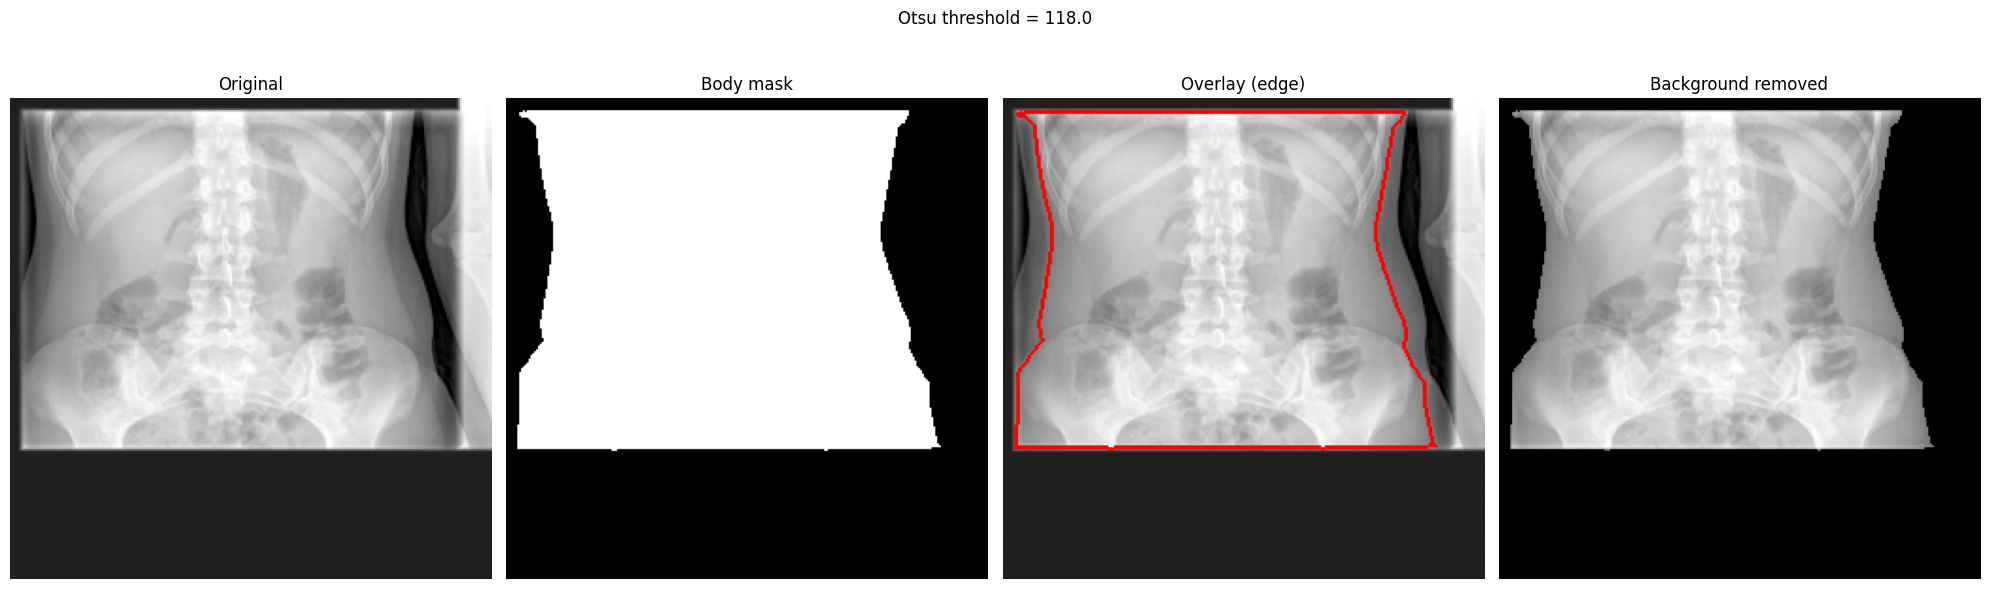

이미지 크기      : (256, 256)
Photometric     : MONOCHROME1
Otsu threshold  : 118.0
신체 영역 비율  : 53.5%


In [35]:
# ▼ 여기에 DICOM 파일 경로 입력
DICOM_PATH = "C:\\Users\\csm02\\Desktop\\edward\\bmd\\src\\BMD\\model\\dataset-dcm\\test\\gather\\1.2.826.0.1.3680043.8.498.10406657579016312201439626146133412368-c.dcm"

img8, ds = load_dicom(DICOM_PATH)
mask, thr = extract_body_mask(img8)
masked = visualize(img8, mask, thr)

# 결과 확인
body_ratio = mask.mean()
print(f"이미지 크기      : {img8.shape}")
print(f"Photometric     : {getattr(ds, 'PhotometricInterpretation', 'N/A')}")
print(f"Otsu threshold  : {thr:.1f}")
print(f"신체 영역 비율  : {body_ratio*100:.1f}%")

## 5. (선택) 결과 저장 & 바운딩 박스

In [36]:
def save_results(img8, mask, out_prefix="body_seg"):
    """마스크와 배경제거 이미지를 PNG로 저장."""
    masked = img8.copy(); masked[~mask] = 0
    cv2.imwrite(f"{out_prefix}_mask.png", (mask * 255).astype(np.uint8))
    cv2.imwrite(f"{out_prefix}_masked.png", masked)
    print(f"저장 완료: {out_prefix}_mask.png, {out_prefix}_masked.png")

def body_bbox(mask):
    """신체 영역의 바운딩 박스 (x, y, w, h) 반환. ROI crop 용."""
    ys, xs = np.where(mask)
    if len(xs) == 0:
        return None
    x0, x1 = xs.min(), xs.max()
    y0, y1 = ys.min(), ys.max()
    return int(x0), int(y0), int(x1 - x0 + 1), int(y1 - y0 + 1)

# 사용 예
# save_results(img8, mask)
# print("BBox (x,y,w,h):", body_bbox(mask))

## 조정 가이드

분리가 잘 안 될 때:

- **배경 일부가 신체로 잡힘** → `min_area_ratio` 높이기 (예: 0.05), collimation(조사야) 영역이면 gradient 기반 crop을 앞단에 추가
- **신체 내부가 뚫림** → `close_radius` 키우기 (예: 8~10)
- **경계가 지나치게 부풀음/축소** → `close_radius` 줄이기, 또는 Otsu 대신 고정 percentile 임계값 사용
- **라벨/마커가 함께 잡힘** → largest connected component가 이미 제거하지만, 라벨이 신체에 붙어있으면 별도 규칙 필요

Otsu로 안 되는 케이스(금속 임플란트, 심한 산란, 복잡한 배경)만 **U-Net / nnU-Net**으로 넘어가면 됩니다.